In [1]:
from SDP_interaction_inference.constraints import Constraint
from SDP_interaction_inference import optimization
from SDP_interaction_inference.dataset import Dataset
from SDP_interaction_inference.correlation import Correlation
from SDP_interaction_inference import utils
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
import scipy
import tqdm
from copy import deepcopy
import matplotlib.patches
import corner
import plotly
import plotly.graph_objects as go

In [2]:
# read fibroblast transcript counts
data_FIB = pd.read_csv("../Real-Data-2/Data/GSE151334_FIB_counts_thresh.csv", index_col=0)

# load capture
beta = np.loadtxt("../Real-Data-2/Capture/beta_FIB.txt")

# load RNA types
biotypes_dict = json.load(open("../Real-Data-2/Biotypes/biotypes_FIB.json"))

# select indices of protein coding mRNA and non-coding miRNA
pcRNA_indices = [idx for idx, btype in enumerate(biotypes_dict.values()) if btype == "protein_coding"]
miRNA_indices = [idx for idx, btype in enumerate(biotypes_dict.values()) if btype == "miRNA"]

# separate data
data_FIB_pcRNA = data_FIB.iloc[pcRNA_indices]
data_FIB_miRNA = data_FIB.iloc[miRNA_indices]

# amounts: see './Biotypes/updated-biotypes.ipynb' for full pie chart of types
print(f"Total of {data_FIB.shape[0]} genes with mean > 1 present \nSelected {data_FIB_miRNA.shape[0]} non-coding miRNA \nSelected {data_FIB_pcRNA.shape[0]} protein coding (mRNA)")

Total of 11747 genes with mean > 1 present 
Selected 19 non-coding miRNA 
Selected 9296 protein coding (mRNA)


In [ ]:
def construct_dataset(mirna_sample, mrna_dataset, beta, resamples=1000):

    # size
    gene_pairs, cells = mrna_dataset.shape

    # construct paired count dataframe
    counts_df = pd.DataFrame(
        index = [f"Gene-pair-{i}" for i in range(gene_pairs)],
        columns = [f"Cell-{j}" for j in range(cells)]
    )

    # fill with pairs
    for i in range(gene_pairs):
        gene_i = mirna_sample
        gene_j = mrna_dataset.iloc[i]
        gene_pair_ij = list(zip(gene_i, gene_j))
        counts_df.iloc[i] = gene_pair_ij

    # construct dataset object
    data = Dataset()
    data.count_dataset = counts_df
    data.cells = cells
    data.gene_pairs = gene_pairs

    # settings
    data.resamples = resamples

    # set capture
    data.beta = beta

    return data

In [5]:
def model_free_independence_test(dataset, d_bd, d_sd, **kwargs):

    # Independent model free
    constraints = Constraint(
        moment_bounds=True,
        moment_matrices=True,
        factorization=True
    )
    opt_MF_ind = optimization.ModelFreeOptimization(dataset, d_bd=d_bd, d_me=0, d_sd=d_sd, constraints=constraints, printing=False, silent=True, **kwargs)
    opt_MF_ind.analyse_dataset()

    # extract results
    status = [solution['status'] for solution in opt_MF_ind.result_dict.values()]
    times  = [solution['time'] for solution in opt_MF_ind.result_dict.values()]
    cuts   = [solution['cuts'] for solution in opt_MF_ind.result_dict.values()]

    # collect
    data = {
        'status': status,
        'times': times,
        'cuts': cuts,
        'model': opt_MF_ind
    }

    return data

In [6]:
def model_free_interacting_test(dataset, d_bd, d_sd, **kwargs):

    # Interacting model free
    constraints = Constraint(
        moment_bounds=True,
        moment_matrices=True,
        factorization=False
    )
    opt_MF_int = optimization.ModelFreeOptimization(dataset, d_bd=d_bd, d_me=0, d_sd=d_sd, constraints=constraints, printing=False, silent=True, **kwargs)
    opt_MF_int.analyse_dataset()

    # extract results
    status = [solution['status'] for solution in opt_MF_int.result_dict.values()]
    times  = [solution['time'] for solution in opt_MF_int.result_dict.values()]
    cuts   = [solution['cuts'] for solution in opt_MF_int.result_dict.values()]
    correlation = [solution['correlation'] for solution in opt_MF_int.result_dict.values()]

    # collect
    data = {
        'status': status,
        'times': times,
        'cuts': cuts,
        'correlation': correlation,
        'model': opt_MF_int
    }

    return data

## Re-run only optimization

In [47]:
# select sample
miRNA = "MIR100"
G = 10
mRNA = data_FIB_pcRNA.index[:G]

# settings
d_boot = 3

# construct dataset of miRNA paired with mRNA
dataset_SDP = construct_dataset(data_FIB_miRNA.loc[miRNA], data_FIB_pcRNA.loc[mRNA], beta)

# bootstrap
dataset_SDP.confidence = 0.95
dataset_SDP.bootstrap(d=d_boot, tqdm_disable=False)

  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:00<00:00, 28.79it/s]


In [48]:
# settings
d_bd = 3
d_sd = 3
time_limit = 30
total_time_limit = 30
cut_limit = 1000

# Model free independence test
constraints = Constraint(
    moment_bounds=True,
    moment_matrices=True,
    factorization=True
)
opt_MF_ind = optimization.ModelFreeOptimization(dataset_SDP, d_bd=d_bd, d_me=0, d_sd=d_sd, constraints=constraints, printing=False, silent=True, time_limit=time_limit, total_time_limit=total_time_limit, cut_limit=cut_limit)
opt_MF_ind.analyse_dataset()
#opt_MF_ind.result_dict

  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:00<00:00, 27.02it/s]


In [49]:
M = 100
recovered_correlations = np.empty((G, M))
for m in tqdm.tqdm(range(M)):

    # Model free interacting test
    constraints = Constraint(
        moment_bounds=True,
        moment_matrices=True,
        factorization=False
    )
    opt_MF_int = optimization.ModelFreeOptimization(dataset_SDP, d_bd=d_bd, d_me=0, d_sd=d_sd, constraints=constraints, printing=False, silent=True, time_limit=time_limit, total_time_limit=total_time_limit, cut_limit=cut_limit, tqdm_disable=True)
    opt_MF_int.analyse_dataset()
    opt_MF_int.result_dict

    for idx, val in opt_MF_int.result_dict.items():
        recovered_correlations[idx, m] = float(val['correlation'])

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:29<00:00,  3.42it/s]


Text(0.5, 1.0, 'Recovered correlation over repeated optimization')

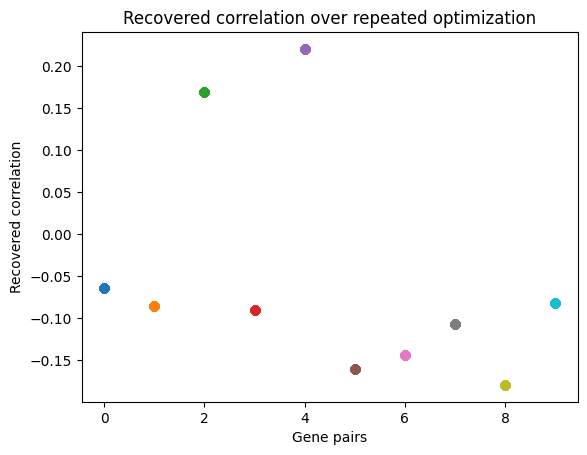

In [50]:
for i in range(G):    
    plt.scatter([i]*M, recovered_correlations[i, :])
plt.xlabel("Gene pairs")
plt.ylabel("Recovered correlation")
plt.title("Recovered correlation over repeated optimization")

## Re-run bootstrap & optimization

In [52]:
# select sample
miRNA = "MIR100"
G = 10
mRNA = data_FIB_pcRNA.index[:G]

# settings
d_boot = 3

# construct dataset of miRNA paired with mRNA
dataset_SDP = construct_dataset(data_FIB_miRNA.loc[miRNA], data_FIB_pcRNA.loc[mRNA], beta)

# confidence
dataset_SDP.confidence = 0.95

In [53]:
M = 100
recovered_correlations_boot = np.empty((G, M))
for m in tqdm.tqdm(range(M)):

    # bootstrap
    dataset_SDP.bootstrap(d=d_boot, tqdm_disable=True)

    # Model free interacting test
    constraints = Constraint(
        moment_bounds=True,
        moment_matrices=True,
        factorization=False
    )
    opt_MF_int = optimization.ModelFreeOptimization(dataset_SDP, d_bd=d_bd, d_me=0, d_sd=d_sd, constraints=constraints, printing=False, silent=True, time_limit=time_limit, total_time_limit=total_time_limit, cut_limit=cut_limit, tqdm_disable=True)
    opt_MF_int.analyse_dataset()
    opt_MF_int.result_dict

    for idx, val in opt_MF_int.result_dict.items():
        recovered_correlations_boot[idx, m] = float(val['correlation'])

100%|██████████| 100/100 [00:53<00:00,  1.87it/s]


Text(0.5, 1.0, 'Recovered correlation over repeated bootstrap & optimization')

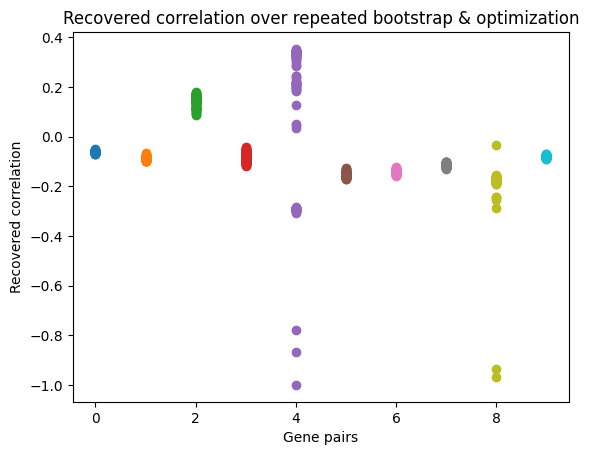

In [54]:
for i in range(G):    
    plt.scatter([i]*M, recovered_correlations_boot[i, :])
plt.xlabel("Gene pairs")
plt.ylabel("Recovered correlation")
plt.title("Recovered correlation over repeated bootstrap & optimization")

## Comparison across order

In [55]:
# select sample
miRNA = "MIR100"
G = 10
mRNA = data_FIB_pcRNA.index[:G]

# settings
d_boot = 3

# construct dataset of miRNA paired with mRNA
dataset_SDP = construct_dataset(data_FIB_miRNA.loc[miRNA], data_FIB_pcRNA.loc[mRNA], beta)

# bootstrap
dataset_SDP.confidence = 0.95
dataset_SDP.bootstrap(d=d_boot, tqdm_disable=False)

100%|██████████| 10/10 [00:00<00:00, 28.77it/s]


In [57]:
M = 10
orders = [(2, 2), (3, 3)]
recovered_correlations_order = np.empty((len(orders), G, M))
for i, (d_bd, d_sd) in enumerate(orders):
    for m in tqdm.tqdm(range(M)):

        # Model free interacting test
        constraints = Constraint(
            moment_bounds=True,
            moment_matrices=True,
            factorization=False
        )
        opt_MF_int = optimization.ModelFreeOptimization(dataset_SDP, d_bd=d_bd, d_me=0, d_sd=d_sd, constraints=constraints, printing=False, silent=True, time_limit=time_limit, total_time_limit=total_time_limit, cut_limit=cut_limit, tqdm_disable=True)
        opt_MF_int.analyse_dataset()
        opt_MF_int.result_dict

        for idx, val in opt_MF_int.result_dict.items():
            recovered_correlations_order[i, idx, m] = float(val['correlation'])

100%|██████████| 10/10 [00:03<00:00,  3.28it/s]


Text(0, 0.5, '(3, 3)')

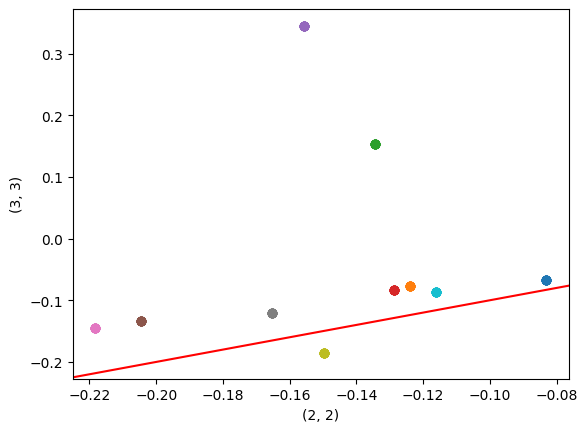

In [61]:
for g in range(G):
    plt.scatter(recovered_correlations_order[0, g, :], recovered_correlations_order[1, g, :])
plt.axline([-0.2, -0.2], [-0.1, -0.1], color="red")
plt.xlabel(orders[0])
plt.ylabel(orders[1])

## SolutionPool trial

- Optimize MF-int as usual until a feasible solution found
- write final model to file
- load model and re-optimize with SolutionPool = n
- for each feasible solution check SDP feasibility
- look at number of SDP feasible points and their spread